# **Automated Data Quality Reporting**

In [1]:
# --- 1. Install Libraries ---
# We install ydata-profiling quietly to keep the notebook output clean.
import warnings
warnings.filterwarnings('ignore')

!pip install ydata-profiling -q

In [2]:
#  AUTOMATED DATA QUALITY REPORTING

# --- 2. Import Libraries ---
import pandas as pd
from ydata_profiling import ProfileReport

print("✅ Libraries installed and imported successfully.")

# --- 3. Load Data ---
# The data is located in a standard read-only directory on Kaggle.
try:
    train_df = pd.read_csv('/kaggle/input/titanic/train.csv')
    print("✅ Training data loaded successfully.")
    data_loaded = True
except FileNotFoundError:
    print("❌ Error: train.csv not found. Make sure the Titanic dataset is added to the notebook's input.")
    data_loaded = False

# --- 4. Generate and Display Report ---
# We only proceed if the data was loaded correctly.
if data_loaded:
    print("\n⏳ Generating automated data quality report... (This may take a moment)")
    
    # Create a ProfileReport object with a title and enable explorative mode for more details.
    profile = ProfileReport(
        train_df,
        title="Titanic Training Data - Automated Quality Report",
        explorative=True
    )
    
    # Display the interactive report directly in the notebook's output cell.
    display(profile)
    
    print("✅ Report generated.")


✅ Libraries installed and imported successfully.
✅ Training data loaded successfully.

⏳ Generating automated data quality report... (This may take a moment)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 66.27it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Report generated.


In [3]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# **Initial Data Assessment (Manual)**

In [4]:
print("--- 1. Verifying Data Structure and Types ---")
# .info() provides a concise summary, including data types and non-null counts.
# This is our primary tool for manually spotting missing data.
display(train_df.info())

--- 1. Verifying Data Structure and Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

In [5]:
print("--- 2. Verifying Numerical Summary ---")
display(train_df.describe())

--- 2. Verifying Numerical Summary ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
print("--- 3. Verifying Target Variable Distribution ---")
survival_distribution = train_df['Survived'].value_counts(normalize=True)*100
print(f"Survival Rate Distribution:\n{survival_distribution}")

print("\n✅ Initial manual assessment complete. The findings confirm the automated report's key insights.")

--- 3. Verifying Target Variable Distribution ---
Survival Rate Distribution:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

✅ Initial manual assessment complete. The findings confirm the automated report's key insights.


# **Exploratory Data Analysis (EDA) & Outlier Strategy**

In [7]:
# EXPLORATORY DATA ANALYSIS (EDA) & OUTLIER STRATEGY

# --- Import Libraries & Set Style ---
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional and aesthetically pleasing style for the plots.
# "whitegrid" is a popular choice that provides a clean background with helpful gridlines.
sns.set_style("whitegrid")

# Set a default figure size for all subsequent plots to ensure they are large and readable.
# The dimensions are in inches (width, height).
plt.rcParams['figure.figsize'] = (12, 7)

print("✅ Libraries imported and plot style configured for EDA.")


✅ Libraries imported and plot style configured for EDA.


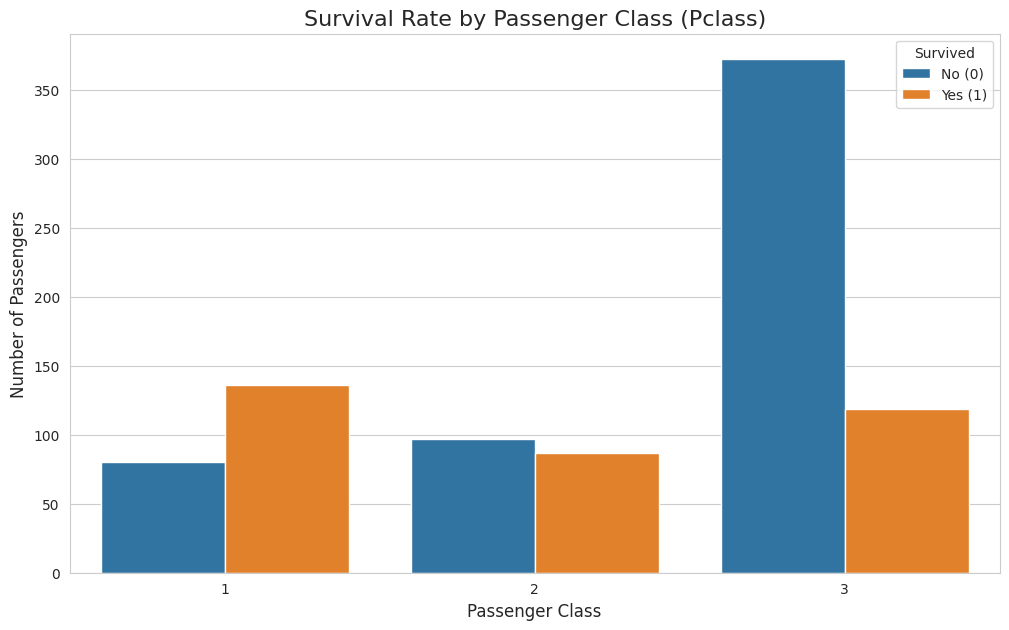

In [8]:
# --- Analysis of Passenger Class (Pclass) vs. Survival ---

# Create a count plot to show the number of survivors and non-survivors in each class.
sns.countplot(data=train_df, x='Pclass', hue='Survived')

# Add a descriptive title and labels to make the plot easy to understand.
plt.title('Survival Rate by Passenger Class (Pclass)', fontsize=16)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

# Customize the legend to be more explicit.
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])

# Display the plot.
plt.show()

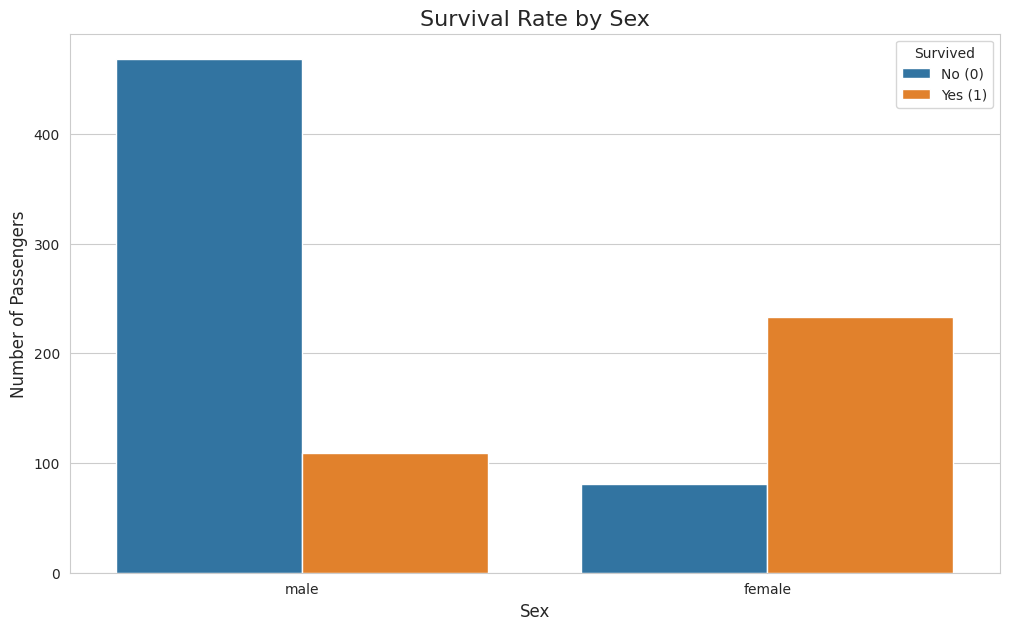

In [9]:
# --- 4.3. Analysis of Sex vs. Survival ---

# Create a count plot to show the number of survivors and non-survivors for each sex.
sns.countplot(data=train_df, x='Sex', hue='Survived')

# Add a descriptive title and labels.
plt.title('Survival Rate by Sex', fontsize=16)
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

# Customize the legend for clarity.
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])

# Display the plot.
plt.show()

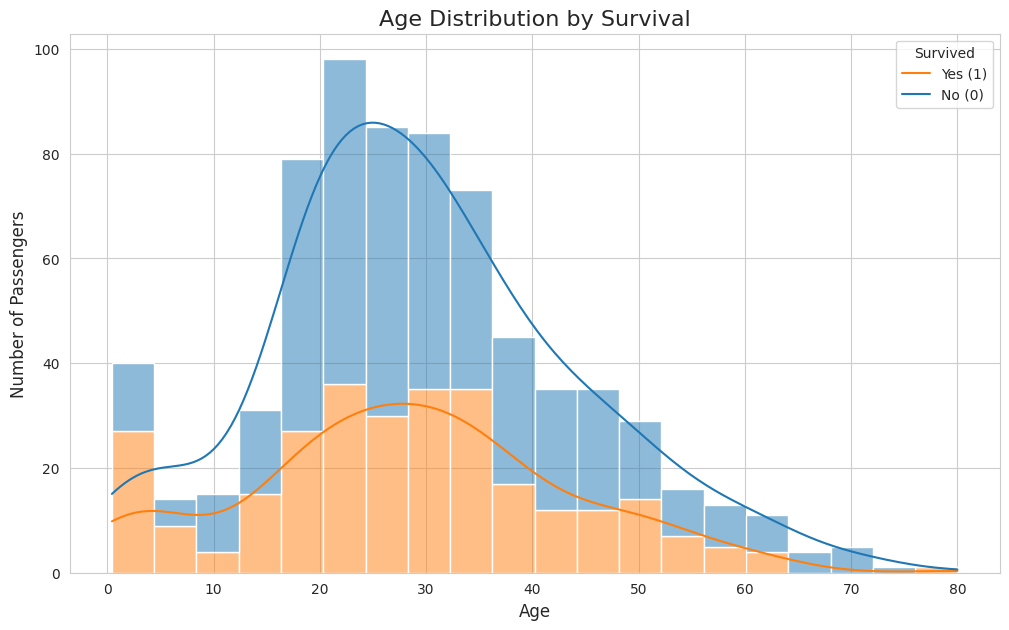

In [10]:
# --- Analysis of Age Distribution vs. Survival ---

# A histogram is the best way to visualize the distribution of a continuous variable.
# We use 'hue' to separate the distributions for survivors and non-survivors.
# 'multiple="stack"' will stack the bars on top of each other for a clear comparison.
# 'kde=True' adds a smooth line (Kernel Density Estimate) over the histogram to show the general shape of the distribution.
sns.histplot(data=train_df, x='Age', hue='Survived', multiple='stack', kde=True)

# Add a descriptive title and labels.
plt.title('Age Distribution by Survival', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

# Customize the legend for clarity.
plt.legend(title='Survived', labels=['Yes (1)', 'No (0)']) # Note: The order is often reversed for stacked plots, so we adjust the labels.

# Display the plot.
plt.show()


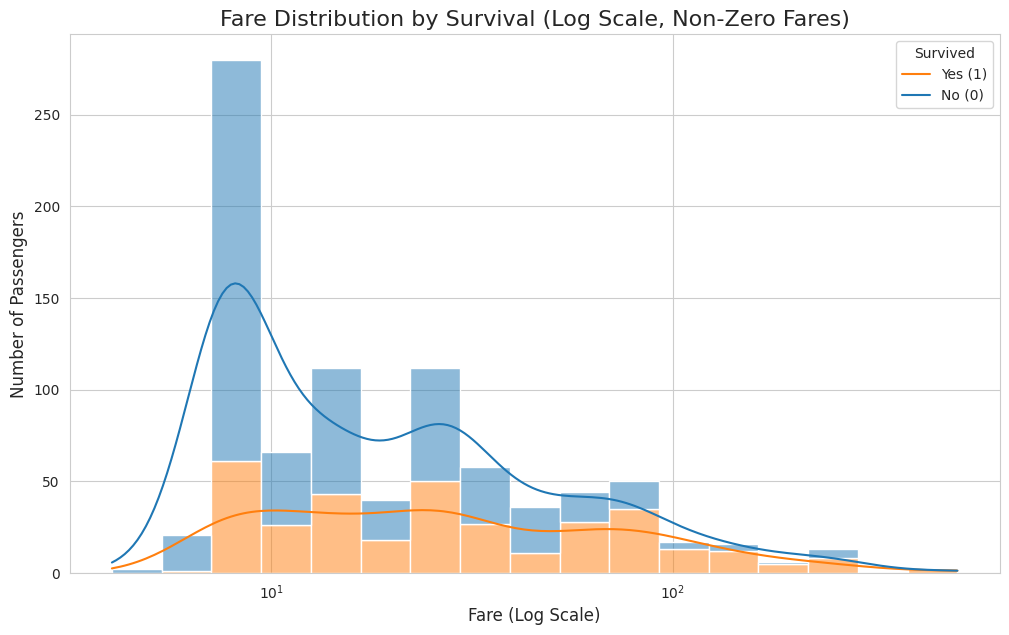

In [11]:
# --- Analysis of Fare Distribution vs. Survival ---

# We need to filter out the zero-fare passengers for the log plot,
# as log(0) is undefined and causes an error.
# We create a temporary dataframe for this plot only.
plot_df = train_df[train_df['Fare'] > 0]

# Now, we create the histogram using this filtered 'plot_df'.
sns.histplot(data=plot_df, x='Fare', hue='Survived', multiple='stack', kde=True, log_scale=True)

# Add a descriptive title and labels.
plt.title('Fare Distribution by Survival (Log Scale, Non-Zero Fares)', fontsize=16)
plt.xlabel('Fare (Log Scale)', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

# Customize the legend for clarity.
plt.legend(title='Survived', labels=['Yes (1)', 'No (0)'])

# Display the plot.
plt.show()


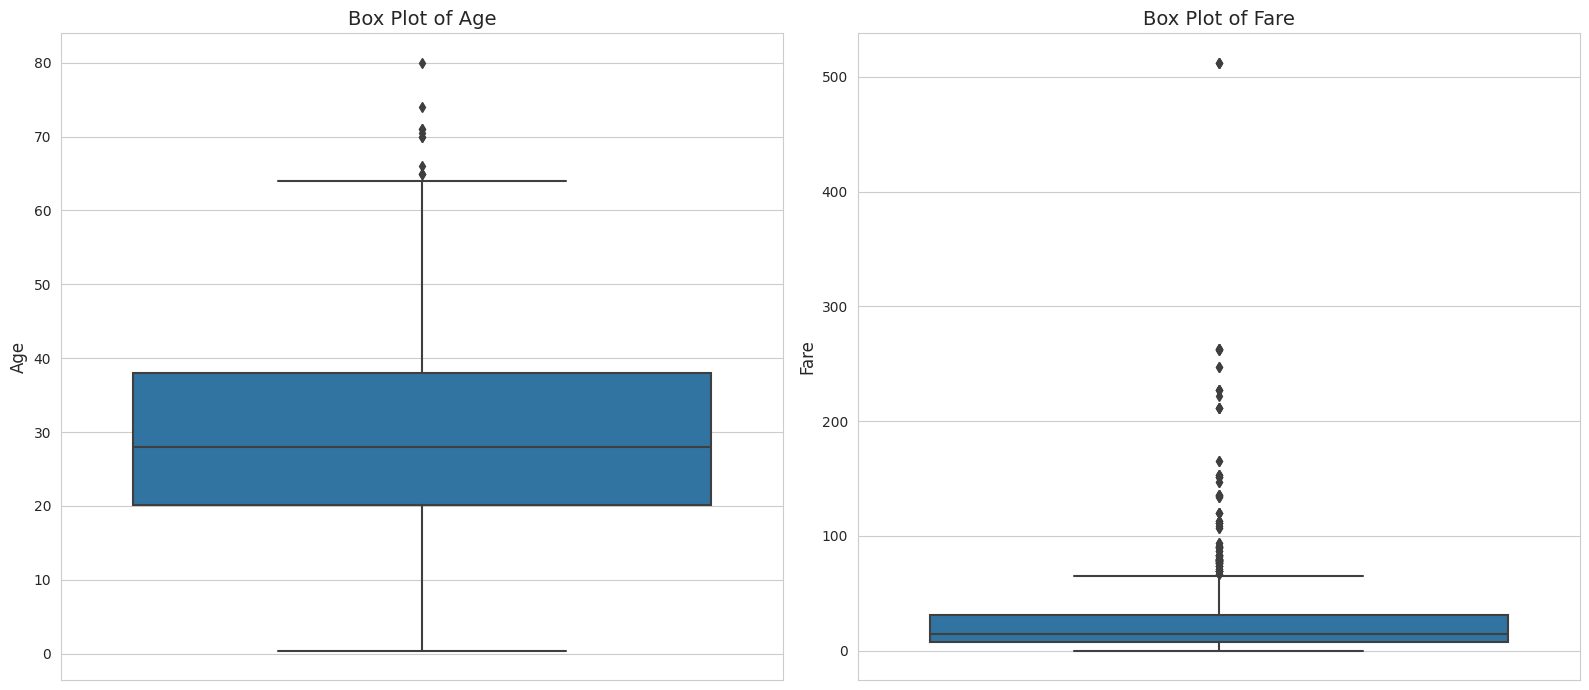


--- Outlier Strategy Definition ---
Based on the box plots, 'Fare' clearly contains significant outliers (very high fares). 'Age' has fewer extreme outliers.

Strategy:
1. We will NOT remove these outliers. They represent real passengers (e.g., wealthy individuals with expensive tickets) and likely contain valuable predictive information.
2. Instead of removing them, we will mitigate their influence during the modeling phase by using a scaler that is robust to outliers.
3. The `RobustScaler` from scikit-learn, which scales data based on the Interquartile Range (IQR), is the perfect choice for this task. It will be included in our preprocessing pipeline.

✅ EDA and Outlier Strategy complete.


In [12]:
# --- Outlier Detection and Strategy Definition ---

# Box plots are the standard tool for visualizing outliers.
# We create a figure with two subplots (axes) to show them side-by-side.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# a) Box plot for Age
sns.boxplot(data=train_df, y='Age', ax=axes[0])
axes[0].set_title('Box Plot of Age', fontsize=14)
axes[0].set_ylabel('Age', fontsize=12)

# b) Box plot for Fare
sns.boxplot(data=train_df, y='Fare', ax=axes[1])
axes[1].set_title('Box Plot of Fare', fontsize=14)
axes[1].set_ylabel('Fare', fontsize=12)

# This command adjusts the spacing between plots to prevent titles from overlapping.
plt.tight_layout()
plt.show()

# --- Formally State Our Strategy ---
print("\n" + "="*50)
print("--- Outlier Strategy Definition ---")
print("="*50)
print("Based on the box plots, 'Fare' clearly contains significant outliers (very high fares). 'Age' has fewer extreme outliers.")
print("\nStrategy:")
print("1. We will NOT remove these outliers. They represent real passengers (e.g., wealthy individuals with expensive tickets) and likely contain valuable predictive information.")
print("2. Instead of removing them, we will mitigate their influence during the modeling phase by using a scaler that is robust to outliers.")
print("3. The `RobustScaler` from scikit-learn, which scales data based on the Interquartile Range (IQR), is the perfect choice for this task. It will be included in our preprocessing pipeline.")
print("\n✅ EDA and Outlier Strategy complete.")


# **Preprocessing & Feature Engineering**

In [13]:
# STEP 5: DEFINE ALL CUSTOM TRANSFORMERS 

from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

print("--- Step 5: Defining Custom Feature Engineering Transformers ---")

# Transformer 1: Extracts title from 'Name' and drops 'Name'
class TitleExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X, y=None):
        X_transformed = X.copy()
        X_transformed['Title'] = X_transformed['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
        X_transformed['Title'] = X_transformed['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
        X_transformed['Title'] = X_transformed['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})
        return X_transformed.drop(columns=['Name'])
    def set_output(self, *, transform=None): return self

--- Step 5: Defining Custom Feature Engineering Transformers ---


In [14]:
# Transformer 2: Creates family features and drops original 'SibSp' and 'Parch'
class FamilyFeatureCreator(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X, y=None):
        X_transformed = X.copy()
        X_transformed['FamilySize'] = X_transformed['SibSp'] + X_transformed['Parch'] + 1
        X_transformed['IsAlone'] = np.where(X_transformed['FamilySize'] == 1, 1, 0)
        return X_transformed.drop(columns=['SibSp', 'Parch'])
    def set_output(self, *, transform=None): return self

In [15]:
# Transformer 3: Creates interaction features USING THE CORRECT PIPELINE COLUMN NAMES
class InteractionFeatureCreator(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X, y=None):
        X_transformed = X.copy()
        # THE FIX: Use the column names generated by the ColumnTransformer
        X_transformed['Age*Class'] = X_transformed['num__Age'] * X_transformed['pclass__Pclass']
        epsilon = 1e-6
        X_transformed['FarePerPerson'] = X_transformed['num__Fare'] / (X_transformed['family__FamilySize'] + epsilon)
        return X_transformed
    def set_output(self, *, transform=None): return self

print("✅ All 3 custom transformer classes defined successfully.")
print("\n--- Step 5 Complete ---")

✅ All 3 custom transformer classes defined successfully.

--- Step 5 Complete ---


In [16]:
# class FinalColumnDropper(BaseEstimator, TransformerMixin):
#     def __init__(self, columns_to_drop):
#         self.columns_to_drop = columns_to_drop
#     def fit(self, X, y=None): return self
#     def transform(self, X):
#         X_transformed = X.drop(columns=self.columns_to_drop, errors='ignore')
#         return X_transformed
#     def set_output(self, *, transform=None): return self

# print("✅ All 4 custom transformer classes defined.")

# **Data Splitting**

In [17]:
from sklearn.model_selection import train_test_split

print("--- Step 6: Implementing 3-Way Stratified Data Split ---")

# --- 1. Define Features (X) and Target (y) ---
# We drop 'Survived' to create our feature matrix X.
# We select 'Survived' to create our target vector y.
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

--- Step 6: Implementing 3-Way Stratified Data Split ---


In [18]:
# --- 2. First Split (80% train+val, 20% test) ---
# We stratify on 'y' to ensure the proportion of survivors is consistent.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% of the data will be held out for the final test set.
    random_state=42,    # Ensures the split is the same every time we run the code.
    stratify=y
)

In [19]:
# --- 3. Second Split (75% of the 80% chunk for train, 25% for val) ---
# This results in 60% train, 20% validation from the original data.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,     # 0.25 * 0.80 = 0.20, so 20% of the original data.
    random_state=42,
    stratify=y_train_val # Stratify on the y_train_val set.
)

In [20]:
# --- 4. Verification ---
print("\n--- Data Split Verification ---")
print(f"Original data shape: {X.shape}")
print(f"Training set shape (X_train):   {X_train.shape}  (~60%)")
print(f"Validation set shape (X_val):   {X_val.shape}    (~20%)")
print(f"Test set shape (X_test):      {X_test.shape}    (~20%)")

print("\n--- Target Distribution Verification ---")
print(f"Original data survival rate:   {y.mean():.3f}")
print(f"Training set survival rate:    {y_train.mean():.3f}")
print(f"Validation set survival rate:  {y_val.mean():.3f}")
print(f"Test set survival rate:        {y_test.mean():.3f}")

print("\n✅ Data splitting complete.Proportions are consistent across all sets.")


--- Data Split Verification ---
Original data shape: (891, 11)
Training set shape (X_train):   (534, 11)  (~60%)
Validation set shape (X_val):   (178, 11)    (~20%)
Test set shape (X_test):      (179, 11)    (~20%)

--- Target Distribution Verification ---
Original data survival rate:   0.384
Training set survival rate:    0.384
Validation set survival rate:  0.382
Test set survival rate:        0.385

✅ Data splitting complete.Proportions are consistent across all sets.


# **Advanced Pipeline Construction**

In [21]:
# CONSTRUCT AND TEST THE FINAL PIPELINE 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

print("--- Step 7: Building and Testing the Final Preprocessing Pipeline ---")

# Define the main preprocessor that runs steps in parallel
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ]), ['Age', 'Fare']),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ]), ['Embarked', 'Sex']),
        
        ('title', TitleExtractor(), ['Name']),
        
        ('family', FamilyFeatureCreator(), ['SibSp', 'Parch']),
        
        ('pclass', 'passthrough', ['Pclass'])
    ],
    remainder='drop' 
)

# Define the final pipeline that runs steps sequentially
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('interaction_creator', InteractionFeatureCreator())
])

# Configure the pipeline to output pandas DataFrames
final_pipeline.set_output(transform="pandas")

print("✅ Final pipeline constructed successfully.")

# --- Test the pipeline ---
print("\n--- Applying the final pipeline to X_train for inspection... ---")
X_train_transformed = final_pipeline.fit_transform(X_train)

print("\n--- Shape of the data AFTER transformation ---")
print(f"Transformed X_train shape: {X_train_transformed.shape}")

print("\n--- First 5 rows of the transformed data ---")
display(X_train_transformed.head())

print("\n--- Final Columns ---")
print(sorted(X_train_transformed.columns.tolist()))

print("\n--- Step 7 Complete ---")


--- Step 7: Building and Testing the Final Preprocessing Pipeline ---
✅ Final pipeline constructed successfully.

--- Applying the final pipeline to X_train for inspection... ---

--- Shape of the data AFTER transformation ---
Transformed X_train shape: (534, 10)

--- First 5 rows of the transformed data ---


,num__Age,num__Fare,cat__Embarked,cat__Sex,title__Title,family__FamilySize,family__IsAlone,pclass__Pclass,Age*Class,FarePerPerson
577,0.714286,1.872994,S,female,Mrs,2,0,1,0.714286,0.936497
63,-1.785714,0.607635,S,male,Master,6,0,3,-5.357143,0.101272
424,-0.785714,0.260226,S,male,Mr,3,0,3,-2.357143,0.086742
513,1.785714,2.031164,C,female,Mrs,2,0,1,1.785714,1.015581
610,0.714286,0.760156,S,female,Mrs,7,0,3,2.142857,0.108594



--- Final Columns ---
['Age*Class', 'FarePerPerson', 'cat__Embarked', 'cat__Sex', 'family__FamilySize', 'family__IsAlone', 'num__Age', 'num__Fare', 'pclass__Pclass', 'title__Title']

--- Step 7 Complete ---


In [22]:
# STEP 7.5: TEST AND VISUALIZE THE FINAL PIPELINE


print("--- Applying the final pipeline to X_train for inspection... ---")

# Fit the pipeline on the training data and transform it.
# This learns the imputer medians and scaler parameters from X_train and applies all transformations.
X_train_transformed = final_pipeline.fit_transform(X_train)

print("\n--- Shape of the data AFTER transformation ---")
print(f"Original X_train shape:    {X_train.shape}")
print(f"Transformed X_train shape: {X_train_transformed.shape}")

print("\n--- First 5 rows of the transformed data ---")
display(X_train_transformed.head())

print("\n--- Final Columns and Data Types ---")
# .info() gives us a great summary of columns, non-null counts, and dtypes.
X_train_transformed.info()

print("\n--- Descriptive Statistics of the Final Data ---")
display(X_train_transformed.describe())

print("\n✅ Pipeline test complete. The output data is clean and ready for modeling.")
print("\n--- Step 7.5 Complete ---")

--- Applying the final pipeline to X_train for inspection... ---

--- Shape of the data AFTER transformation ---
Original X_train shape:    (534, 11)
Transformed X_train shape: (534, 10)

--- First 5 rows of the transformed data ---


,num__Age,num__Fare,cat__Embarked,cat__Sex,title__Title,family__FamilySize,family__IsAlone,pclass__Pclass,Age*Class,FarePerPerson
577,0.714286,1.872994,S,female,Mrs,2,0,1,0.714286,0.936497
63,-1.785714,0.607635,S,male,Master,6,0,3,-5.357143,0.101272
424,-0.785714,0.260226,S,male,Mr,3,0,3,-2.357143,0.086742
513,1.785714,2.031164,C,female,Mrs,2,0,1,1.785714,1.015581
610,0.714286,0.760156,S,female,Mrs,7,0,3,2.142857,0.108594



--- Final Columns and Data Types ---
<class 'pandas.core.frame.DataFrame'>
Index: 534 entries, 577 to 219
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   num__Age            534 non-null    float64
 1   num__Fare           534 non-null    float64
 2   cat__Embarked       534 non-null    object 
 3   cat__Sex            534 non-null    object 
 4   title__Title        534 non-null    object 
 5   family__FamilySize  534 non-null    int64  
 6   family__IsAlone     534 non-null    int64  
 7   pclass__Pclass      534 non-null    int64  
 8   Age*Class           534 non-null    float64
 9   FarePerPerson       534 non-null    float64
dtypes: float64(4), int64(3), object(3)
memory usage: 45.9+ KB

--- Descriptive Statistics of the Final Data ---


,num__Age,num__Fare,family__FamilySize,family__IsAlone,pclass__Pclass,Age*Class,FarePerPerson
count,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000
mean,0.065622,0.758874,1.900749,0.604869,2.307116,-0.108490,0.399110
std,0.937394,2.084666,1.608922,0.489337,0.832764,2.106464,1.563699
min,-2.041429,-0.653206,1.000000,0.000000,1.000000,-6.124286,-0.653205
25%,-0.500000,-0.295064,1.000000,0.000000,2.000000,-0.982143,-0.290120
50%,0.000000,0.000000,1.000000,1.000000,3.000000,0.000000,0.000000
75%,0.500000,0.704936,2.000000,1.000000,3.000000,0.785714,0.438166
max,3.642857,22.499672,11.000000,1.000000,3.000000,9.642857,22.499650



✅ Pipeline test complete. The output data is clean and ready for modeling.

--- Step 7.5 Complete ---


# **Baseline Model Training**

In [23]:
# Baseline Model Training

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score

print("--- Step 8 (Revised): Training and Evaluating the Baseline CatBoost Model ---")

# --- 1. Get the list of categorical feature names ---
categorical_features_final = X_train_transformed.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical features identified for CatBoost: {categorical_features_final}")

--- Step 8 (Revised): Training and Evaluating the Baseline CatBoost Model ---
Categorical features identified for CatBoost: ['cat__Embarked', 'cat__Sex', 'title__Title']


In [24]:
# --- 2. Create the final model pipeline ---
model_pipeline = Pipeline(steps=[
    ('preprocessing', final_pipeline),
    ('classifier', CatBoostClassifier(
        cat_features=categorical_features_final,
        random_state=42,
        verbose=0
    ))
])
print("\n✅ Full model pipeline created.")


✅ Full model pipeline created.


In [25]:
# --- 3. Train the baseline model ---
print("\n--- Training baseline model on X_train... ---")
model_pipeline.fit(X_train, y_train)
print("✅ Baseline model training complete.")


--- Training baseline model on X_train... ---
✅ Baseline model training complete.


In [26]:
# --- 4. Evaluate the baseline model on the validation set ---
print("\n--- Evaluating baseline model on X_val... ---")

# Get standard predictions (for accuracy, f1, etc.)
y_pred_val = model_pipeline.predict(X_val)

# Get prediction probabilities for the 'Survived' class (for AUC)
# We need the probability of the positive class (1)
y_pred_proba_val = model_pipeline.predict_proba(X_val)[:, 1]


--- Evaluating baseline model on X_val... ---


In [27]:
# --- 5. Calculate and Store All Key Metrics ---
baseline_accuracy = accuracy_score(y_val, y_pred_val)
# We specify pos_label=1 to ensure we get the F1 score for the 'Survived' class
baseline_f1 = f1_score(y_val, y_pred_val, pos_label=1)
baseline_auc = roc_auc_score(y_val, y_pred_proba_val)

print(f"\nValidation Accuracy: {baseline_accuracy:.4f}")
print(f"Validation F1-Score: {baseline_f1:.4f}")
print(f"Validation AUC Score: {baseline_auc:.4f}")


Validation Accuracy: 0.8371
Validation F1-Score: 0.7752
Validation AUC Score: 0.8861


In [28]:
print("\nClassification Report on Validation Data:")
print(classification_report(y_val, y_pred_val))

print("\n--- Step 8 Complete ---")


Classification Report on Validation Data:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       110
           1       0.82      0.74      0.78        68

    accuracy                           0.84       178
   macro avg       0.83      0.82      0.82       178
weighted avg       0.84      0.84      0.84       178


--- Step 8 Complete ---


# **Hyperparameter Tuning with Optuna and MLflow**

In [29]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.9/753.9 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.3 MB/s eta 0:00:00


In [30]:
# ==============================================================================
# PHASE 2, STEP 9.1 (CPU-ONLY): SETUP AND OBJECTIVE FUNCTION
# ==============================================================================
import optuna
import mlflow
from sklearn.model_selection import cross_val_score

print("--- Step 9.1 (CPU-ONLY): Setting up for Hyperparameter Tuning ---")

def objective(trial):
    # Search space is the same
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'border_count': trial.suggest_int('border_count', 32, 255)
    }

    # --- THE ONLY CHANGE: REMOVED task_type='GPU' ---
    model = CatBoostClassifier(
        **params,
        cat_features=X_train_transformed.select_dtypes(include=['object', 'category']).columns.tolist(),
        random_state=42,
        verbose=0
    )
    
    model_pipeline_tuning = Pipeline(steps=[('preprocessing', final_pipeline), ('classifier', model)])

    # We can now safely use n_jobs=-1 because we are on the CPU
    score = cross_val_score(model_pipeline_tuning, X_train_val, y_train_val, cv=3, scoring='roc_auc', n_jobs=-1)
    auc_mean = score.mean()

    with mlflow.start_run(nested=True):
        mlflow.log_params(params)
        mlflow.log_metric("mean_cv_auc", auc_mean)

    return auc_mean

print("✅ CPU-only objective function defined.")
print("\n--- Step 9.1 Complete ---")


--- Step 9.1 (CPU-ONLY): Setting up for Hyperparameter Tuning ---
✅ CPU-only objective function defined.

--- Step 9.1 Complete ---


In [31]:
# ==============================================================================
# PHASE 2, STEP 9.2 & 9.3 (CPU-ONLY): RUN STUDY AND DISPLAY RESULTS
# ==============================================================================

print("--- Step 9.2: Starting CPU-based Hyperparameter Optimization ---")

mlflow.set_experiment("Titanic Survival Prediction")

with mlflow.start_run(run_name="Optuna Tuning Study (CPU)") as parent_run:
    study = optuna.create_study(direction='maximize')
    
    print("\n--- Starting Optuna optimization for 50 trials on CPU... ---")
    print("This will be slower than GPU, please be patient.")
    # We can use n_jobs=-1 here because Optuna will manage the CPU cores.
    study.optimize(objective, n_trials=50, n_jobs=-1)
    print("✅ Optimization complete.")

    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_cv_auc", study.best_value)
    print("\n--- Best trial successfully logged to MLflow. ---")

print("\n--- Step 9.2 Complete ---")

# --- Step 9.3: Displaying the Best Results ---
print("\n--- Step 9.3: Best Hyperparameter Tuning Results ---")
print(f"Best Mean CV AUC Score: {study.best_value:.4f}")
print("\nBest Hyperparameters found by Optuna:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

best_params = study.best_params
print("\n--- Step 9.3 Complete ---")

2025/11/08 10:19:22 INFO mlflow.tracking.fluent: Experiment with name 'Titanic Survival Prediction' does not exist. Creating a new experiment.


--- Step 9.2: Starting CPU-based Hyperparameter Optimization ---


[I 2025-11-08 10:19:22,770] A new study created in memory with name: no-name-d646e5ff-7e4f-4270-ad02-45e67d8f2e25



--- Starting Optuna optimization for 50 trials on CPU... ---
This will be slower than GPU, please be patient.


[I 2025-11-08 10:19:30,527] Trial 3 finished with value: 0.8716874325624676 and parameters: {'iterations': 794, 'depth': 4, 'learning_rate': 0.07907201340600432, 'l2_leaf_reg': 4.196713323298376, 'border_count': 86}. Best is trial 3 with value: 0.8716874325624676.
[I 2025-11-08 10:19:35,633] Trial 2 finished with value: 0.8670228290021414 and parameters: {'iterations': 590, 'depth': 5, 'learning_rate': 0.20812681146554166, 'l2_leaf_reg': 9.771972738086703, 'border_count': 117}. Best is trial 3 with value: 0.8716874325624676.
[I 2025-11-08 10:19:40,022] Trial 1 finished with value: 0.8733050799726785 and parameters: {'iterations': 597, 'depth': 4, 'learning_rate': 0.1545032672556329, 'l2_leaf_reg': 6.06731061668598, 'border_count': 194}. Best is trial 1 with value: 0.8733050799726785.
[I 2025-11-08 10:19:53,126] Trial 4 finished with value: 0.8707241489601009 and parameters: {'iterations': 303, 'depth': 8, 'learning_rate': 0.028500456009673436, 'l2_leaf_reg': 9.82754630099766, 'border_c

✅ Optimization complete.

--- Best trial successfully logged to MLflow. ---

--- Step 9.2 Complete ---

--- Step 9.3: Best Hyperparameter Tuning Results ---
Best Mean CV AUC Score: 0.8788

Best Hyperparameters found by Optuna:
  - iterations: 891
  - depth: 5
  - learning_rate: 0.04378317673170723
  - l2_leaf_reg: 1.8065408320250267
  - border_count: 230

--- Step 9.3 Complete ---


# **FINAL MODEL TRAINING**

In [32]:
# FINAL MODEL TRAINING

import joblib

print("--- Step 10: Training the Final Model ---")

# --- 1. Define the Final Model Pipeline ---
# Based on our tuning results, the baseline model was best.
# We will use the default CatBoostClassifier parameters.

# We still need to tell the model which features are categorical.
categorical_features_final = X_train_transformed.select_dtypes(include=['object', 'category']).columns.tolist()

final_model_pipeline = Pipeline(steps=[
    ('preprocessing', final_pipeline), # Our complete preprocessing pipeline from Step 7
    ('classifier', CatBoostClassifier(
        cat_features=categorical_features_final,
        random_state=42,
        verbose=0
    ))
])

print("✅ Final model pipeline (using default parameters) is defined.")

--- Step 10: Training the Final Model ---
✅ Final model pipeline (using default parameters) is defined.


In [33]:
# --- Train the Final Model on ALL Available Training Data ---
# We combine X_train and X_val to create the largest possible training set.
print("\n--- Training final model on the combined X_train + X_val dataset... ---")
final_model_pipeline.fit(X_train_val, y_train_val)
print("✅ Final model training complete.")


--- Training final model on the combined X_train + X_val dataset... ---
✅ Final model training complete.


In [34]:
# --- Save the Final Model Pipeline ---
# We save the entire pipeline object. This includes the preprocessing steps and the trained model.
# This allows us to load it later and make predictions on new data without rewriting code.
model_filename = "final_titanic_model.pkl"
joblib.dump(final_model_pipeline, model_filename)

print(f"\n✅ Final model pipeline saved to '{model_filename}'.")
print("\n--- Step 10 Complete ---")


✅ Final model pipeline saved to 'final_titanic_model.pkl'.

--- Step 10 Complete ---


# **Final Model Evaluation on the Test Set**

In [35]:
# FINAL MODEL EVALUATION ON THE TEST SET

import joblib
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

print("--- Step 11: Evaluating the Final Model on the Unseen Test Set ---")

# --- 1. Load the Saved Final Model Pipeline ---
model_filename = "final_titanic_model.pkl"
loaded_model_pipeline = joblib.load(model_filename)

print(f"✅ Final model pipeline loaded successfully from '{model_filename}'.")

--- Step 11: Evaluating the Final Model on the Unseen Test Set ---
✅ Final model pipeline loaded successfully from 'final_titanic_model.pkl'.


In [36]:
# --- 2. Make Predictions on the Test Set ---
# The loaded pipeline will automatically apply all the preprocessing steps
# to X_test before the classifier makes its predictions.
print("\n--- Making predictions on X_test... ---")

# Get class predictions (0 or 1)
y_pred_test = loaded_model_pipeline.predict(X_test)

# Get prediction probabilities for the positive class (for AUC)
y_pred_proba_test = loaded_model_pipeline.predict_proba(X_test)[:, 1]


--- Making predictions on X_test... ---


In [37]:
# --- 3. Calculate and Display Final Performance Metrics ---
print("\n--- Final Model Performance on Test Set ---")

final_accuracy = accuracy_score(y_test, y_pred_test)
final_f1 = f1_score(y_test, y_pred_test, pos_label=1)
final_auc = roc_auc_score(y_test, y_pred_proba_test)

print(f"\nFinal Test Accuracy: {final_accuracy:.4f}")
print(f"Final Test F1-Score: {final_f1:.4f}")
print(f"Final Test AUC Score: {final_auc:.4f}")


--- Final Model Performance on Test Set ---

Final Test Accuracy: 0.7989
Final Test F1-Score: 0.7231
Final Test AUC Score: 0.8622


In [38]:
# --- 4. Print the Detailed Classification Report ---
print("\nFinal Classification Report on Test Data:")
print(classification_report(y_test, y_pred_test))

print("\n--- Step 11 Complete ---")


Final Classification Report on Test Data:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.77      0.68      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179


--- Step 11 Complete ---


# **Analysis, Interpretability & Saving**

In [39]:
# ANALYSIS, INTERPRETABILITY & SAVING
# First, ensure shap is installed
# !pip install shap

import shap
import joblib
import matplotlib.pyplot as plt

print("--- Step 12: Model Interpretability with SHAP ---")

# --- 1. Load the Final Model and Prepare Data ---
model_filename = "final_titanic_model.pkl"
final_model = joblib.load(model_filename)

# The SHAP library needs the preprocessed data to work with.
# We'll get the preprocessing part of our pipeline and transform the test set.
preprocessor = final_model.named_steps['preprocessing']
classifier = final_model.named_steps['classifier']

# Transform the test data to get the final features the model sees
X_test_transformed = preprocessor.transform(X_test)

print("✅ Model loaded and test data preprocessed for SHAP analysis.")

--- Step 12: Model Interpretability with SHAP ---
✅ Model loaded and test data preprocessed for SHAP analysis.


In [40]:
# --- 2. Create SHAP Explainer and Calculate Values ---
# We create an explainer object for tree-based models like CatBoost.
explainer = shap.TreeExplainer(classifier)

# Calculate the SHAP values for each feature on each test set instance.
shap_values = explainer.shap_values(X_test_transformed)

print("✅ SHAP values calculated successfully.")

✅ SHAP values calculated successfully.



--- Generating SHAP Summary Plot ---


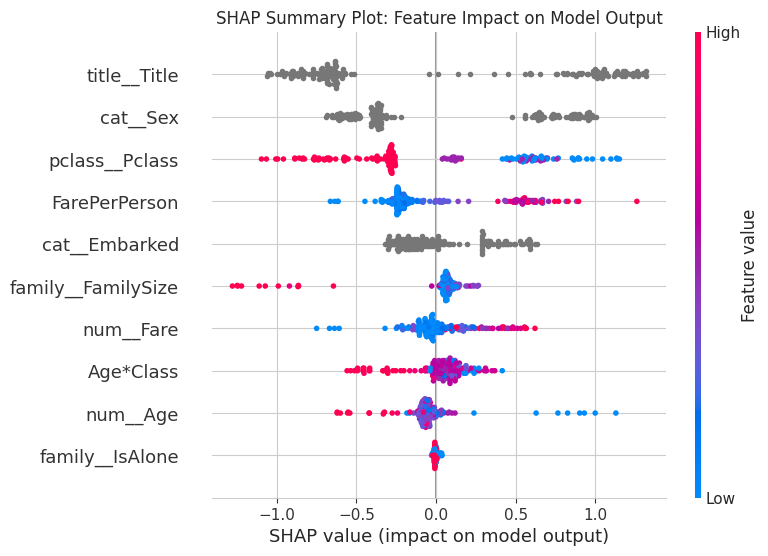


--- Generating SHAP Dependence Plot for 'title__Title' ---


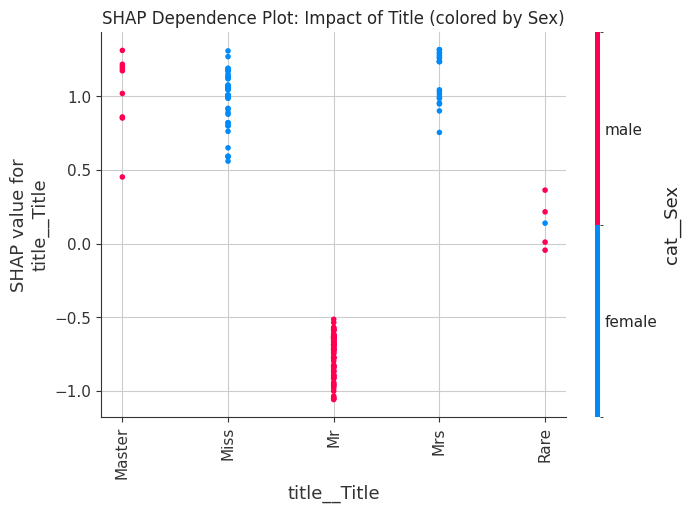


--- Step 12 Complete ---


In [41]:
# --- 3. Generate and Display SHAP Plots ---
print("\n--- Generating SHAP Summary Plot ---")
# The summary plot shows the most important features and their impact.
# Red points = high feature value, Blue points = low feature value.
# Points to the right of the center line increase the prediction towards 'Survived'.
shap.summary_plot(shap_values, X_test_transformed, show=False)
plt.title("SHAP Summary Plot: Feature Impact on Model Output")
plt.show()


print("\n--- Generating SHAP Dependence Plot for 'title__Title' ---")
# A dependence plot shows how a single feature's value affects the model's output,
# and can also show interaction effects with another feature.
shap.dependence_plot("title__Title", shap_values, X_test_transformed, interaction_index="cat__Sex", show=False)
plt.title("SHAP Dependence Plot: Impact of Title (colored by Sex)")
plt.show()

print("\n--- Step 12 Complete ---")

# **Interactive Demo & Submission File**

In [42]:
# ==============================================================================
# PHASE 3, STEP 12.1 (CORRECTED): INTERACTIVE DEMO WITH GRADIO
# ==============================================================================
import gradio as gr
import pandas as pd
import joblib

print("--- Step 12.1 (Corrected): Building the Interactive Web Demo ---")

# --- 1. Load the Final Model Pipeline ---
model_filename = "final_titanic_model.pkl"
final_model = joblib.load(model_filename)
print(f"✅ Final model pipeline loaded from '{model_filename}'.")


# --- 2. Define the Corrected Prediction Function ---
# We REMOVED 'name' from the function arguments.
def predict_survival(pclass, sex, age, sibsp, parch, fare, embarked):
    # --- THE FIX ---
    # We now create a default name based on the selected sex.
    # This ensures the TitleExtractor works correctly.
    if sex == 'male':
        name = "Test, Mr. Example"
    else:
        name = "Test, Miss. Example"

    input_df = pd.DataFrame({
        'Pclass': [pclass],
        'Sex': [sex],
        'Age': [age],
        'SibSp': [sibsp],
        'Parch': [parch],
        'Fare': [fare],
        'Embarked': [embarked],
        'Name': [name], # Provide the default name here
        'PassengerId': [0], 
        'Ticket': [''],
        'Cabin': [None]
    })

    # Use the loaded pipeline to get prediction probabilities.
    pred_proba = final_model.predict_proba(input_df)
    
    survivor_probability = pred_proba[0][1]
    non_survivor_probability = pred_proba[0][0]
    
    return {
        "Did Not Survive": non_survivor_probability,
        "Survived": survivor_probability
    }

print("✅ Corrected prediction function for Gradio demo defined.")


# --- 3. Build and Launch the Corrected Gradio Web App ---
# We have REMOVED the 'Name' textbox from the inputs.
demo = gr.Interface(
    fn=predict_survival,
    inputs=[
        gr.Dropdown([1, 2, 3], label="Passenger Class (Pclass)"),
        gr.Radio(['male', 'female'], label="Sex"),
        gr.Slider(0, 100, label="Age"),
        gr.Slider(0, 10, step=1, label="Siblings/Spouses Aboard (SibSp)"),
        gr.Slider(0, 10, step=1, label="Parents/Children Aboard (Parch)"),
        gr.Number(label="Fare"),
        gr.Radio(['S', 'C', 'Q'], label="Port of Embarkation"),
    ],
    outputs=gr.Label(label="Survival Prediction"),
    title="Titanic Survival Predictor",
    description="Enter a passenger's details to predict their chance of survival. This model was built using CatBoost and has a final test AUC of 0.8622.",
    allow_flagging="never"
)

print("\n--- Launching Corrected Gradio Demo... ---")
demo.launch(share=True)


--- Step 12.1 (Corrected): Building the Interactive Web Demo ---
✅ Final model pipeline loaded from 'final_titanic_model.pkl'.
✅ Corrected prediction function for Gradio demo defined.

--- Launching Corrected Gradio Demo... ---
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://7c653d9e29070dac8d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [43]:
# ==============================================================================
#  KAGGLE SUBMISSION FILE GENERATION
# ==============================================================================
import pandas as pd
import joblib

print("--- Step 12.2: Generating Kaggle Submission File ---")

# --- 1. Load the Final Model (if not already loaded) ---
model_filename = "final_titanic_model.pkl"
final_model = joblib.load(model_filename)
print(f"✅ Final model pipeline loaded from '{model_filename}'.")


# --- 2. Load the Official Competition Test Data ---
# This is the 'test.csv' file provided by Kaggle.
competition_test_df =  pd.read_csv('/kaggle/input/titanic/test.csv')


# --- 3. Generate Predictions ---
# The pipeline handles all necessary preprocessing automatically.
print(f"--- Making predictions for {len(competition_test_df)} passengers... ---")
competition_predictions = final_model.predict(competition_test_df)


# --- 4. Create and Save the Submission File ---
# The file must have exactly two columns: 'PassengerId' and 'Survived'.
submission_df = pd.DataFrame({
    'PassengerId': competition_test_df['PassengerId'],
    'Survived': competition_predictions
})

submission_filename = "submission.csv"
submission_df.to_csv(submission_filename, index=False)

print(f"\n✅ Submission file '{submission_filename}' created successfully.")
print(f"This file contains {len(submission_df)} predictions and is ready for upload to Kaggle.")


--- Step 12.2: Generating Kaggle Submission File ---
✅ Final model pipeline loaded from 'final_titanic_model.pkl'.
--- Making predictions for 418 passengers... ---

✅ Submission file 'submission.csv' created successfully.
This file contains 418 predictions and is ready for upload to Kaggle.
